<a href="https://colab.research.google.com/github/NxrFesdac/bourbaki-nlp-avanzado/blob/main/modulo5/Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U langchain_community openai langchain_openai faiss-cpu langgraph

In [ ]:
import os
import getpass
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

# 1. Configuración de la API Key
api_key = getpass.getpass("Introduce tu OpenAI API Key: ")
os.environ["OPENAI_API_KEY"] = api_key

# 2. RAG y base de datos
politicas = [
    Document(page_content="Política Estándar: Se permiten devoluciones dentro de los 30 días para un reembolso completo."),
    Document(page_content="Política Extendida: Las devoluciones entre 31-60 días reciben solo crédito de la tienda."),
    Document(page_content="Política de Defectos: Los artículos con defectos de fabricación (agujeros, roturas) obtienen un reembolso completo hasta los 90 días."),
]
vector_db = FAISS.from_documents(politicas, OpenAIEmbeddings())
retriever = vector_db.as_retriever()

order_db = {
    "ORD-101": {"articulo": "Botas de Cuero", "fecha_entrega": "2024-01-10", "estado": "entregado"},
}

# 3. Definición de Herramientas
@tool
def consultar_pedido(order_id: str):
    """Consulta los datos del pedido, incluyendo la fecha de entrega y el estado."""
    return order_db.get(order_id, "Pedido no encontrado.")

@tool
def buscar_politica(query: str):
    """Busca en la base de conocimientos las políticas de devolución y reembolso."""
    docs = retriever.invoke(query)
    return "\n".join([d.page_content for d in docs])

# 4. Creación del Agente
system_prompt = (
    "Eres un Agente de Soporte al Cliente. FECHA DE HOY: 2024-02-20. "
    "Usa consultar_pedido para verificar fechas y buscar_politica para ver las reglas. "
    "Si se permite un reembolso, confírmalo al usuario."
)

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
tools = [consultar_pedido, buscar_politica]
memory = MemorySaver()

app = create_react_agent(
    model=model,
    tools=tools,
    prompt=system_prompt,
    checkpointer=memory
)

# 5. Ejecución
config = {"configurable": {"thread_id": "usuario_1"}}
user_input = "Mis botas (ORD-101) tienen un agujero. Las he tenido por 40 días. ¿Puedo obtener un reembolso completo?"

for event in app.stream({"messages": [("user", user_input)]}, config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

Introduce tu OpenAI API Key: ··········


/tmp/ipykernel_3606/1109137464.py:50: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  app = create_react_agent(


================================ Human Message =================================

Mis botas (ORD-101) tienen un agujero. Las he tenido por 40 días. ¿Puedo obtener un reembolso completo?
================================== Ai Message ==================================
Tool Calls:
  consultar_pedido (call_LpM2YHxClTfpesdtgGZ6OfLD)
 Call ID: call_LpM2YHxClTfpesdtgGZ6OfLD
  Args:
    order_id: ORD-101
  buscar_politica (call_9pdIrhnwFiEyHEk0W1ixowD1)
 Call ID: call_9pdIrhnwFiEyHEk0W1ixowD1
  Args:
    query: política de reembolso y devolución para botas con defecto
================================= Tool Message =================================
Name: buscar_politica

Política de Defectos: Los artículos con defectos de fabricación (agujeros, roturas) obtienen un reembolso completo hasta los 90 días.
Política Estándar: Se permiten devoluciones dentro de los 30 días para un reembolso completo.
Política Extendida: Las devoluciones entre 31-60 días reciben solo crédito de la tienda.
============

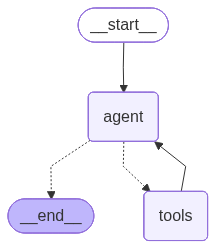

In [ ]:
from IPython.display import Image, display

# Función para visualizar la estructura del agente
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
import pandas as pd
from IPython.display import display

def visualizar_memoria(app, thread_id):
    print(f"\n--- Inspección de Memoria para el Hilo: {thread_id} ---")

    # 1. Obtener el estado actual usando el config
    config = {"configurable": {"thread_id": thread_id}}
    state = app.get_state(config)

    # 2. Extraer el historial de mensajes
    messages = state.values.get("messages", [])

    data = []
    for i, msg in enumerate(messages):
        # Identificar el tipo de remitente
        role = msg.__class__.__name__.replace("Message", "")

        data.append({
            "Paso": i + 1,
            "Rol": role,
            "Resumen de Contenido": msg.content
        })

    df = pd.DataFrame(data)
    display(df)

# Llamar a la función
visualizar_memoria(app, "usuario_1")


--- Inspección de Memoria para el Hilo: usuario_1 ---


,Paso,Rol,Resumen de Contenido
0,1,Human,Mis botas (ORD-101) tienen un agujero. Las he ...
1,2,AI,
2,3,Tool,"{""articulo"": ""Botas de Cuero"", ""fecha_entrega""..."
3,4,Tool,Política de Defectos: Los artículos con defect...
4,5,AI,Tus botas fueron entregadas el 10 de enero de ...


In [ ]:
# 1. Definir la nueva herramienta de Reemplazo
@tool
def solicitar_reemplazo(order_id: str, articulo: str):
    """Procesa una solicitud de reemplazo para un artículo específico."""
    # En una aplicación real, esto actualizaría una base de datos
    return f"Pedido de reemplazo creado para {articulo} (Pedido Original: {order_id}). Envío en 2-3 días."

# 2. Actualizar el Agente con la nueva herramienta
# Reutilizamos la misma 'memoria' y 'modelo' de las celdas anteriores
tools = [consultar_pedido, buscar_politica, solicitar_reemplazo]

app = create_react_agent(
    model=model,
    tools=tools,
    prompt=system_prompt,
    checkpointer=memory
)

# 3. Llamada posterior (Hablando con la misma memoria)
config = {"configurable": {"thread_id": "usuario_1"}}

follow_up_input = "En realidad, no quiero un reembolso, preferiría un par de botas nuevas."

print(f"--- Seguimiento para thread_id: {config['configurable']['thread_id']} ---")

for event in app.stream({"messages": [("user", follow_up_input)]}, config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

/tmp/ipykernel_3606/2033941002.py:12: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  app = create_react_agent(


--- Seguimiento para thread_id: usuario_1 ---
================================ Human Message =================================

En realidad, no quiero un reembolso, preferiría un par de botas nuevo.
================================== Ai Message ==================================
Tool Calls:
  solicitar_reemplazo (call_TkcdYK2kbMxvyL6vjvcnGAJW)
 Call ID: call_TkcdYK2kbMxvyL6vjvcnGAJW
  Args:
    order_id: ORD-101
    articulo: Botas de Cuero
================================= Tool Message =================================
Name: solicitar_reemplazo

Pedido de reemplazo creado para Botas de Cuero (Pedido Original: ORD-101). Envío en 2-3 días.
================================== Ai Message ==================================

He creado un pedido de reemplazo para tus botas de cuero. El nuevo par será enviado en 2-3 días. ¿Hay algo más en lo que pueda ayudarte?
